# 3. Local hotspots of interaction

Notebooks 01 and 02 both return one number per cell type pair. Neither tells you *where*
in the tissue an interaction is happening — a cell type pair can be strongly coupled in
one anatomical region and silent everywhere else.

The **inflow score** works per cell. It quantifies how much a given cell is *influenced*
by neighboring ligand-producing cells through **spatial weighting** of ligand and receptor
expression. This captures both the **directionality** and **locality** of intercellular
signaling, giving a fine-grained view of communication "flows".

$$
\text{Inflow}_{i,s,\ell,r} =
\left(
\frac{
\sum_{j=1}^{n} W_{ij}\,L_{j,\ell}\,C_{j,s}
}{
\sum_{j=1}^{n} W_{ij}
}
\right)
R_{i,r}
$$

where:

- $W_{ij}$ — spatial connectivity weight between target cell *i* and neighboring cell *j*.
- $L_{j,\ell}$ — expression of ligand $\ell$ in cell *j*.
- $C_{j,s}$ — hard filter, 1 if cell *j* belongs to cell type *s*, otherwise 0.
- $R_{i,r}$ — expression of receptor *r* in target cell *i*.
- $n$ — total number of cells.

In other words, the inflow score measures how strongly a cell is **receiving** ligand
signals from its spatial neighborhood, accounting for both spatial proximity and cell-type
context.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as p9

import squidpy as sq
import liana as li

adata = sc.read_h5ad("../../data/brain_section.h5ad")
adata

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts', None (.X)

## Calculate the spatial connectivity matrix $W_{ij}$

Before calculating the inflow score, we first need to define the **spatial connectivity
matrix** $W_{ij}$, which encodes how strongly each cell $i$ is connected to its spatial
neighbors $j$. In essence, $W_{ij}$ determines the *neighborhood* over which ligand
signals are integrated — it specifies *who can talk to whom* in the tissue space.

### Choosing the right bandwidth

Recall from spot notebook 01: `li.pp.query_bandwidth` shows how many neighbours each
observation would have at each bandwidth, and `li.pp.spatial_neighbors` turns the chosen
bandwidth — the $\sigma$ of a Gaussian kernel — into $W_{ij}$. The difference here is scale:
at single-cell resolution we want a neighbourhood of a few cell diameters, not of several
Visium spots. With the default `cutoff=0.1`, weights below 0.1 are set to 0.

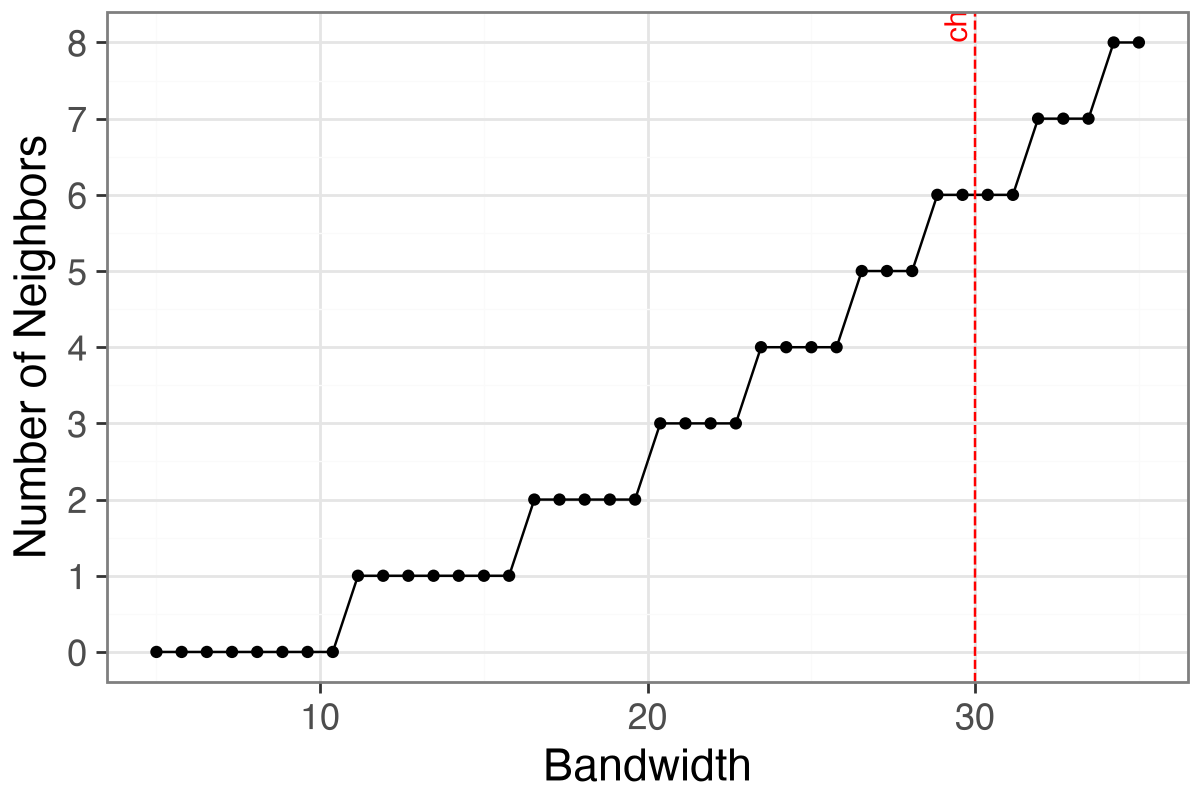

In [2]:
plot, df = li.pp.query_bandwidth(
    coordinates=adata.obsm["X_spatial_coords"],
    start=5,
    end=35,
    interval_n=40
)

bandwidth = 30
plot + p9.geom_vline(xintercept=bandwidth, linetype="dashed", color="red") + \
       p9.annotate("text", x=bandwidth, y=df.neighbours.max(),
                label=f"chosen={bandwidth}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       p9.scale_y_continuous(breaks=range(int(df.neighbours.min()),
                                       int(df.neighbours.max())+1))

Use the chosen bandwidth to compute the final spatial connectivity matrix $W_{ij}$.

In [3]:
li.pp.spatial_neighbors(adata=adata, bandwidth=bandwidth, spatial_key="X_spatial_coords")

#### Visualize proximity

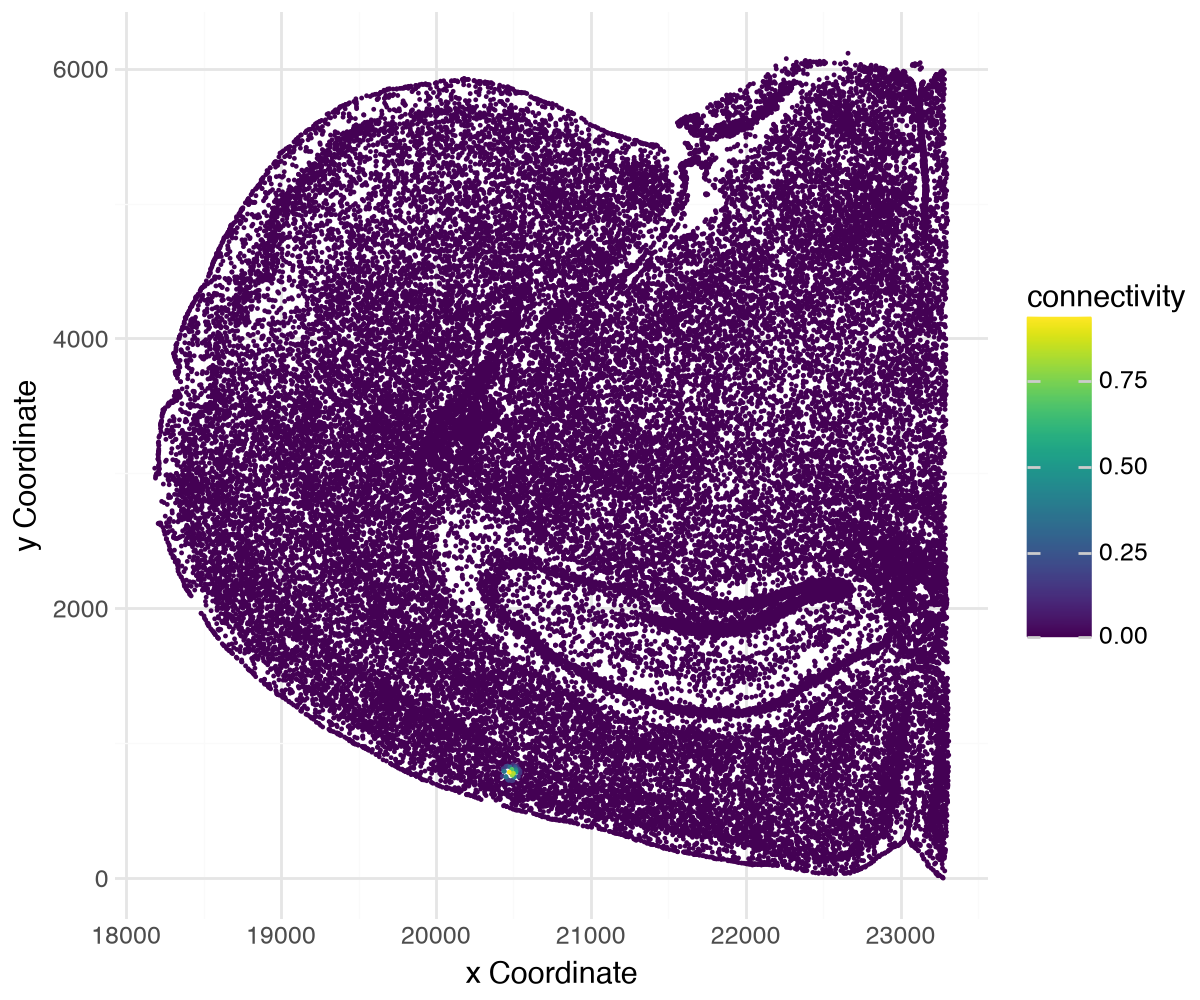

In [4]:
li.pl.connectivity(adata, idx=5500, size=0.01, figure_size=(6, 5), spatial_key="X_spatial_coords")

## Filter to spatially variable genes (SVGs)

The inflow score is computed for every (sender cell type × ligand × receptor) combination,
which is a lot of columns. Restricting to genes with spatial structure — measured by
Moran's I — removes genes that cannot produce a spatial hotspot anyway. In this targeted
brain panel nearly every gene is spatially patterned, so the filter barely bites (1,022 of
1,120 genes pass); on transcriptome-wide data it is what keeps the output interpretable and
the computation cheap.

In [5]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [6]:
adata.uns['moranI']
#I: Moran's I score for each gene
#pval_norm: p-value (normal approximation)
#var_norm: Variance used to normalize Moran's I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
Slc17a7,0.579891,0.000000,0.000002,0.000000
Clic6,0.571128,0.000000,0.000002,0.000000
Neurod2,0.548018,0.000000,0.000002,0.000000
Baiap3,0.529356,0.000000,0.000002,0.000000
C1ql2,0.520750,0.000000,0.000002,0.000000
...,...,...,...,...
Ccdc192,0.000572,0.341959,0.000002,0.342570
Vsx2,0.000483,0.364730,0.000002,0.365056
Dmbx1,0.000203,0.439200,0.000002,0.439200
Pax8,-0.000943,0.262366,0.000002,0.263306


In [7]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1022

In [8]:
adata = adata[:, svgs]

## Compute the inflow score

In [9]:
resource = li.rs.select_resource('mouseconsensus')

lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource=resource,
                      # keep the pre-2.0 default; `Ntf3^Ntrk3` inflow is sparse and is masked at the new default of 0.05
                      nz_prop=0.001,
                      use_raw=False)

lrdata.shape

(51539, 1713)

### Optional: keep only spatially variable LR interactions

The same Moran's I filter, now applied to the inflow scores themselves.

In [10]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [11]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

1410

In [12]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
smooth muscle cell^Sostdc1^Lrp4,0.499171,0.0,0.000002,0.0
glutamatergic neuron^Gnb3^Gabbr2,0.534637,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Efna5^Epha7,0.542253,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Efna5^Epha4,0.554863,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Wnt5a^Epha7,0.560920,0.0,0.000002,0.0
tanycyte^Efna5^Ephb1,0.566245,0.0,0.000002,0.0
glutamatergic neuron^Efna5^Epha4,0.605522,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Ntf3^Ntrk3,0.675003,0.0,0.000002,0.0
tanycyte^Wnt5a^Fzd5,0.754212,0.0,0.000002,0.0
glutamatergic neuron^Ntf3^Ntrk3,0.815907,0.0,0.000002,0.0


## Visualizations

**1. Spatial inflow intensity for a single ligand–receptor interaction.** <br>
Here, we focus on a single interaction to illustrate the spatial distribution of inferred
signaling. Specifically, we show signal sourced from **glutamatergic neurons** via the
ligand **Ntf3** and received through the receptor **Ntrk3**. The inflow intensity reflects
the strength of inferred ligand–receptor–mediated signaling at each spatial location.

In [13]:
#Define variables
cell_type_col = "cell_type"
brain_regions = "major_brain_region"
spatial_key = "X_spatial_coords"

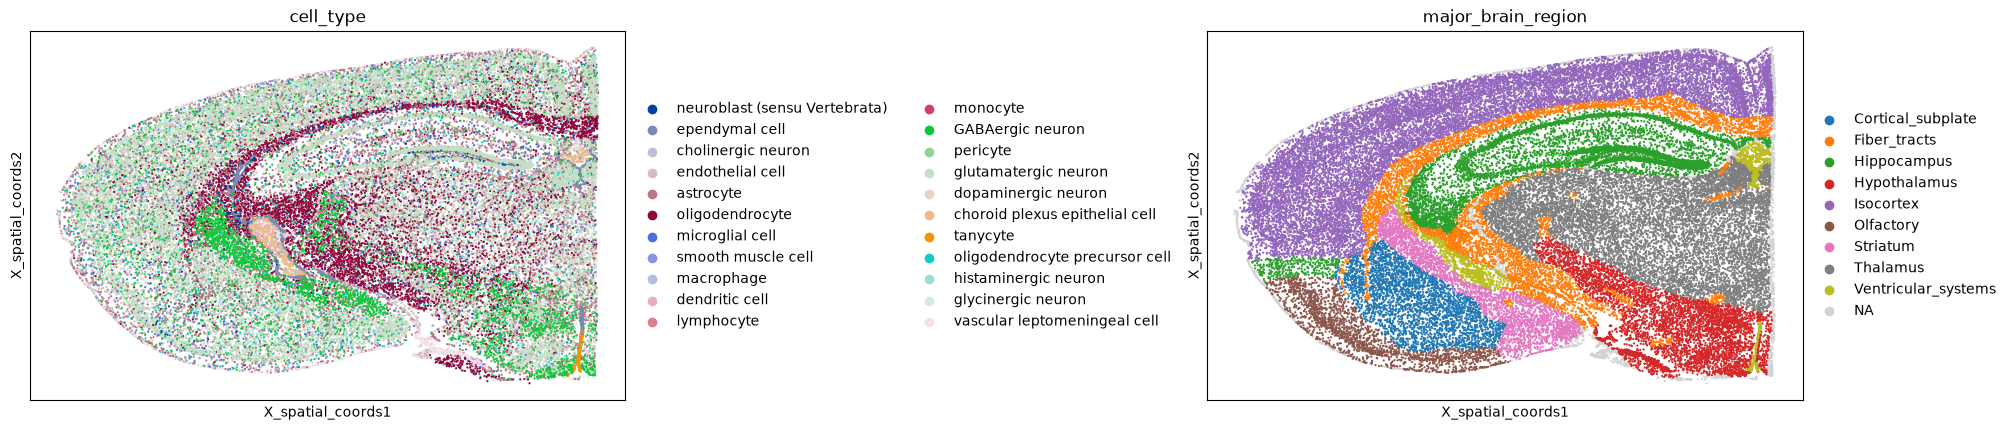

In [14]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=[cell_type_col, brain_regions],
    s=10,
    ncols=2,
    cmap="RdBu_r",
    wspace=0.8
)

In [15]:
interaction = 'glutamatergic neuron^Ntf3^Ntrk3'
comp = interaction.split("^")

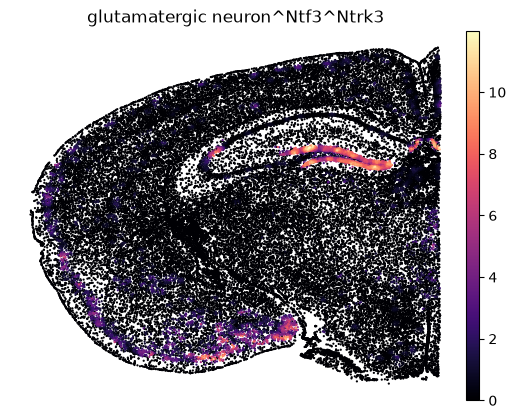

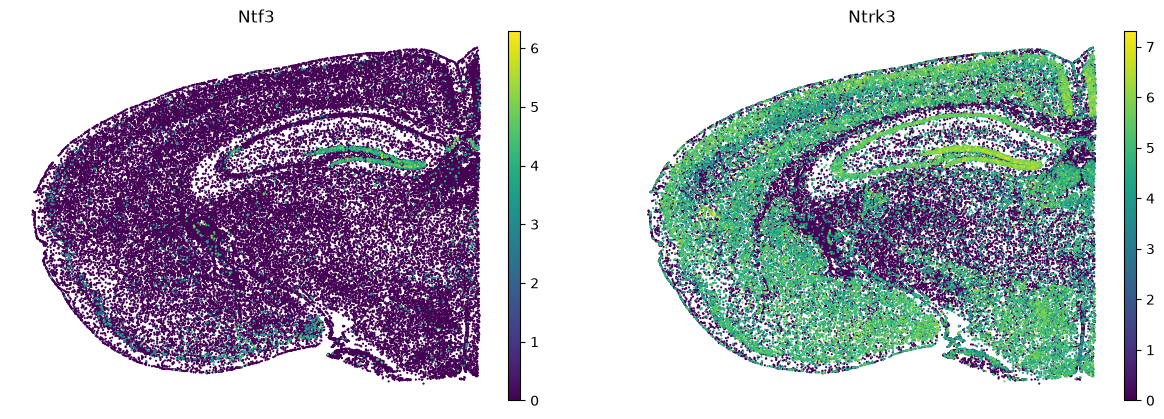

In [16]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=interaction,
    s=10,
    ncols=2,
    cmap='magma',
    frameon=False
)

sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[comp[1], comp[2]],
    s=10,
    use_raw=False,
    ncols=2,
    frameon=False
)

Where are the sender cells themselves?

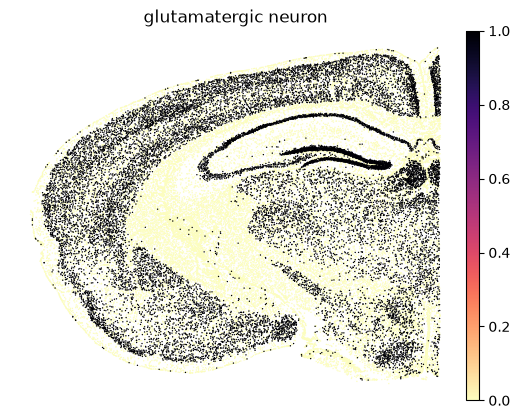

In [17]:
mask = adata.obs[cell_type_col] == 'glutamatergic neuron'
adata.obs['glutamatergic neuron'] = 0
adata.obs.loc[mask, 'glutamatergic neuron'] = 1
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color='glutamatergic neuron',
    s=4,
    use_raw=False,
    ncols=2,
    cmap='magma_r',
    frameon=False
)

**2. Rank cell types receiving inflow from the glutamatergic neuron–Ntf3–Ntrk3 axis.** <br>
Cell types with higher inflow values indicate stronger inferred reception of this
signaling interaction. **Neuroblasts** have the highest mean inflow, followed by
glutamatergic neurons themselves and **oligodendrocyte precursor cells**; in GABAergic
neurons and astrocytes only a minority of cells (~9–14%) receive any.

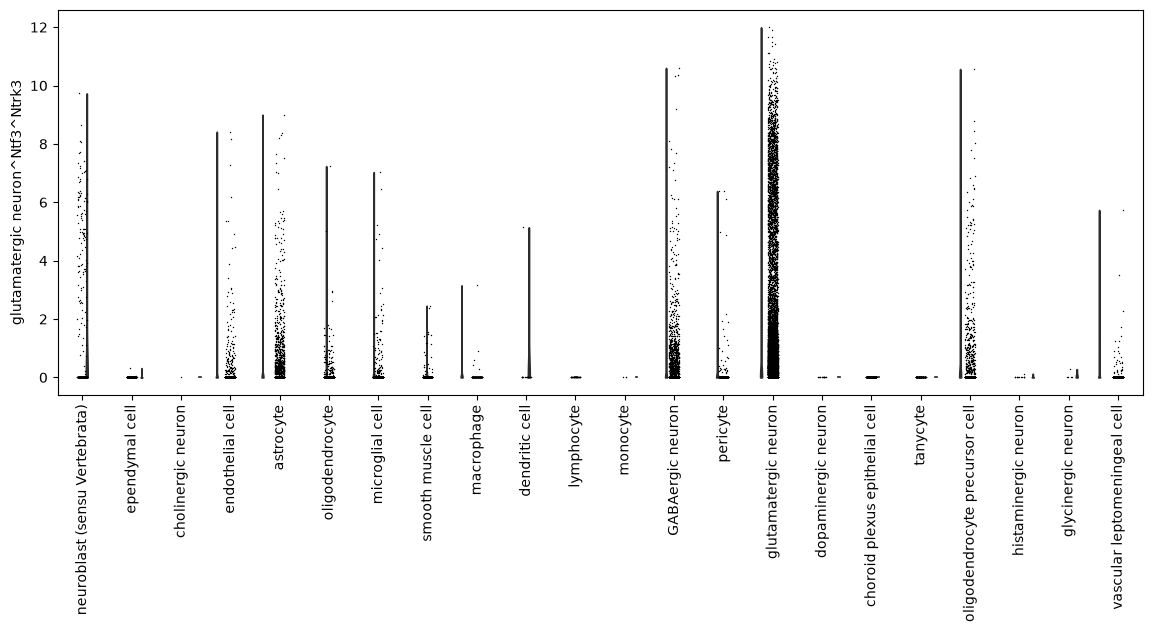

<Figure size 640x480 with 0 Axes>

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

sc.pl.violin(lrdata, groupby=cell_type_col, keys=interaction, rotation=90, ax=ax)

plt.tight_layout()
plt.show()

**3. Spatial location of the cells receiving the signal.** <br>

Cells are split by cell type, and colour intensity reflects the strength of the inferred
inflow received through the Ntrk3 receptor. <br>

Signaling from glutamatergic neurons via Ntf3 is received by neuroblasts (sensu Vertebrata)
mainly in the hippocampus (80% of receiving neuroblasts). In contrast,
the GABAergic neurons, astrocytes and oligodendrocyte precursor cells that receive it are
scattered across isocortex, cortical subplate, striatum and thalamus. <br>

`normalize=True` rescales each receiver type to 0–1 on its own, so colour intensities
show *where* within a cell type the signal is strongest, but cannot be compared across
receiver types — use the violin plot above for that. <br>

This is the payoff of a per-cell score: the same interaction has *different receivers in
different places*, which neither a cell type pair ranking nor a g(r) curve can show.

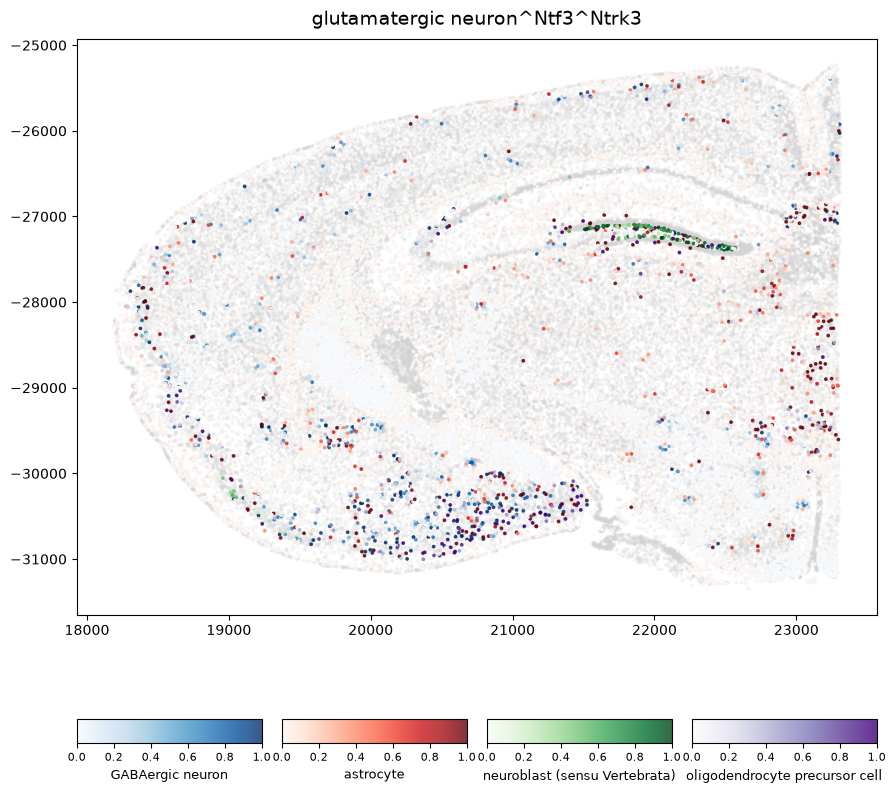

In [19]:
li.pl.feature_by_group(
    adata=lrdata,
    spatial_key=spatial_key,
    feature=interaction,
    groupby=cell_type_col,
    percentile_scaling = (1,97),
    labels=["GABAergic neuron", 'astrocyte', "neuroblast (sensu Vertebrata)", "oligodendrocyte precursor cell"],
    show_counts=False,
    normalize=True,
    figure_size=(10,8)
)
plt.show()

## Global summaries

In addition to the high resolution inflow (single-cell level), we can summarize to get
global scores and specificity for each interaction across (receiver) cell types:

In [20]:
li.mt.compute_global_specificity(lrdata, groupby='cell_type',
                                 n_perms=100, verbose=True, use_raw=False)

Running 100 permutations in parallel...
Running permutations: 100%|██████████| 100/100 [00:05<00:00, 19.98it/s]
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.2s finished


In [21]:
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(3)

,source,ligand_complex,receptor_complex,target,lr_mean,pval
632,choroid plexus epithelial cell,Col18a1,Gpc4,choroid plexus epithelial cell,3.066473,0.009901
105,tanycyte,Efna5,Ephb1,tanycyte,2.985570,0.009901
2285,GABAergic neuron,Hdc,Hrh3,histaminergic neuron,1.961863,0.009901


<div style="border-left:5px solid #f9a825; background:#fffde7; padding:10px 14px; border-radius:4px; margin:12px 0;">

**⚠️ Keep in mind:** imaging data have their own artefacts. Transcripts from one cell can be
assigned to a neighbour (segmentation error, spillover), which creates false co-expression.
Third in this table is `Hdc → Hrh3` sent by *GABAergic neurons* — but `Hdc` (histamine
synthesis) marks histaminergic neurons (detected in 86% of them). Of the 283 GABAergic
neurons with any `Hdc`, 251 carry a single transcript. Before believing a sender, check
the ligand's expression map.
</div>

We can use the global summary to find the cell type pairs that are specific to the **Ntf3 → Ntrk3** axis:

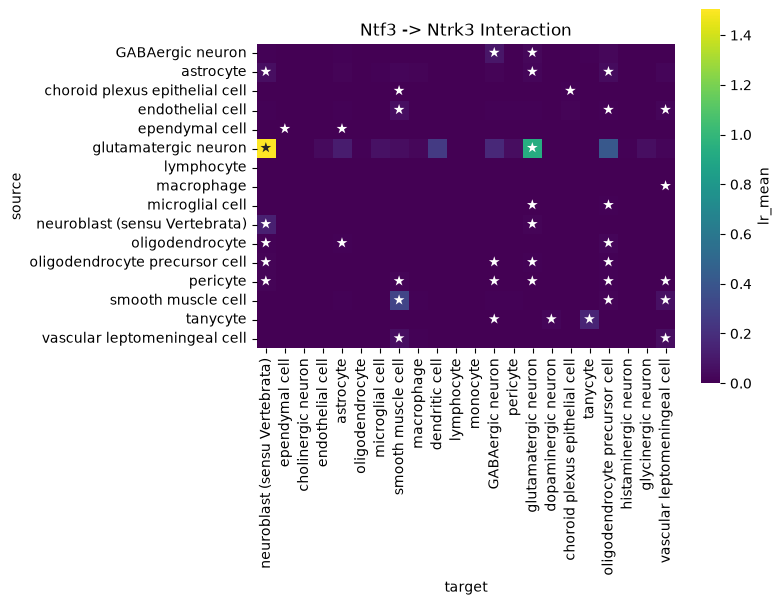

In [22]:
df = lrdata.uns['global_interactions']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')].copy()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    data= interaction_df.pivot_table(index='source', columns='target', values='lr_mean'),
    annot=interaction_df.pivot(index='source', columns='target', values='pval').map(lambda x: '★' if x < 0.05 else ''),
    fmt='',
    square=True,
    annot_kws={'fontfamily': 'DejaVu Sans'},
    cmap='viridis',
    cbar_kws={'label': 'lr_mean'}
)
plt.title('Ntf3 -> Ntrk3 Interaction')
plt.tight_layout()
plt.show()

★ marks `pval < 0.05` from 100 permutations, **uncorrected**: the global table holds
~31,000 tests, so ~1,500 stars are expected by chance alone (3,016 are observed). Treat them
as a guide, not a result — the same holds for dot size below.

We can also identify the top ligand–receptor pairs used by a specific source cell type.
Here we focus again on **glutamatergic neurons** as the signaling source.

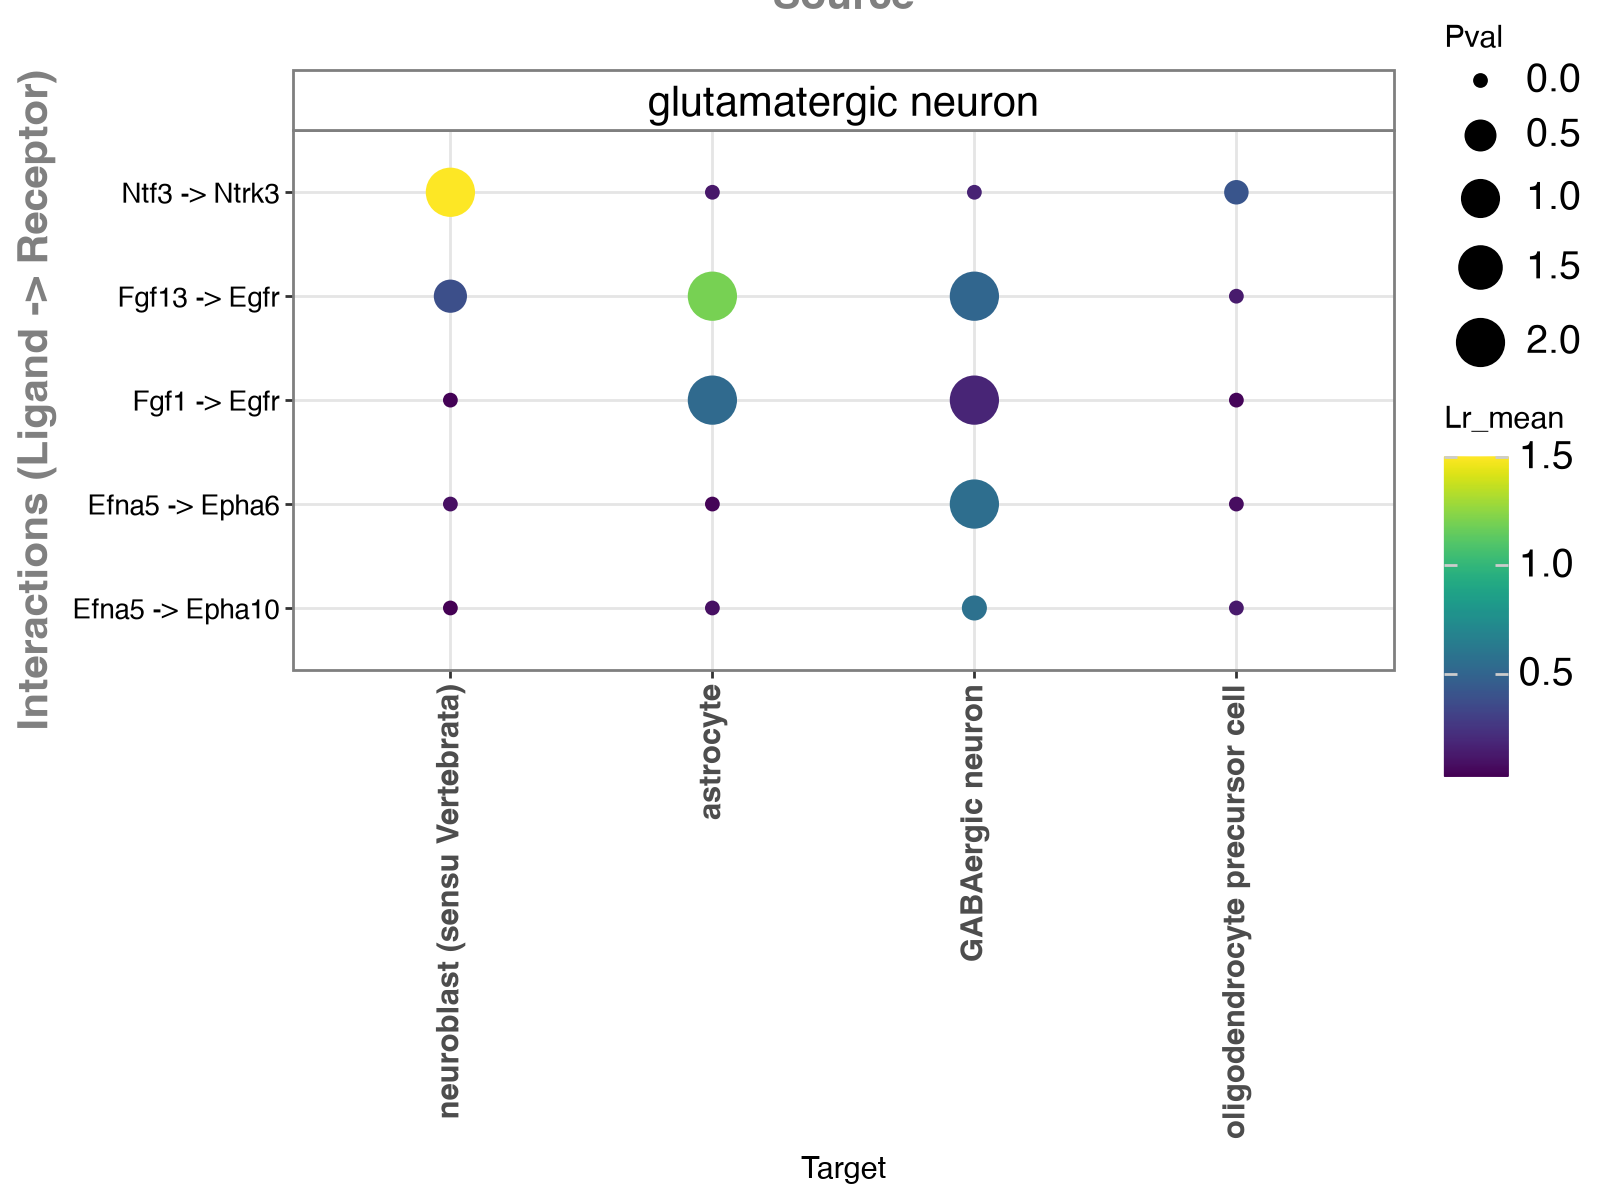

In [23]:
li.pl.dotplot(adata = lrdata,
              colour="lr_mean",
              size ='pval',
              source_labels=["glutamatergic neuron"],
              target_labels=['neuroblast (sensu Vertebrata)', "astrocyte", "oligodendrocyte precursor cell", "GABAergic neuron"],
              filter_fn=lambda x: x['lr_mean'] > 0.5,
              inverse_size=True,
              figure_size=(8,6),
              uns_key='global_interactions'
             )

---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — How sharp is a hotspot?**

The `bandwidth` chosen above (30 µm) sets the neighbourhood over which ligand signal is
integrated — and therefore how sharp or how smeared a hotspot looks. Here it is the
$\sigma$ of a Gaussian kernel.

Recompute `li.pp.spatial_neighbors` and `li.mt.inflow` at `bandwidth=10` and
`bandwidth=100`, and plot the `glutamatergic neuron^Ntf3^Ntrk3` map for each. Pass
`max_neighbours=750`, otherwise the default cap of 100 neighbours truncates the
neighbourhoods at 100 µm.

Which bandwidth would you trust, and what would you look at to decide?
</div>

In [24]:
for bw in [10, 30, 100]:
    # max_neighbours=750: at 100 µm the default cap of 100 would truncate almost every neighbourhood
    li.pp.spatial_neighbors(adata=adata, bandwidth=bw, max_neighbours=750, spatial_key="X_spatial_coords")
    # ... recompute inflow and plot `interaction`
    print(bw)

# restore the chosen bandwidth before continuing
li.pp.spatial_neighbors(adata=adata, bandwidth=bandwidth, spatial_key="X_spatial_coords")

10
30
100


<details>
<summary><b>Solution</b></summary>

```python
for bw in [10, 30, 100]:
    li.pp.spatial_neighbors(adata=adata, bandwidth=bw, max_neighbours=750,
                            spatial_key="X_spatial_coords")
    tmp = li.mt.inflow(adata, groupby='cell_type', resource=resource,
                       nz_prop=0.001, use_raw=False)
    sc.pl.embedding(tmp, basis=spatial_key, color=interaction, s=10,
                    cmap='magma', frameon=False, title=f"bandwidth={bw} µm")

# restore the chosen bandwidth before continuing
li.pp.spatial_neighbors(adata=adata, bandwidth=bandwidth, spatial_key="X_spatial_coords")
```

At `bandwidth=10` the median cell has only 3 neighbours, so the map is sparse and noisy —
close to plotting receptor expression alone. At `bandwidth=100` the ligand signal is averaged
over a wide neighbourhood: the hotspot stays in the hippocampus but broadens (44% of cells get
a non-zero score, vs 19% at 30 µm).

There is no single correct bandwidth. Pick one that matches the signalling range you care
about, and check that the hotspot you report does not hinge on it.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick another interaction — either a different sender cell type for `Ntf3^Ntrk3`, or a
different LR pair entirely — and remake the spatial map and the violin plot.

```python
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(20)
```

Does its hotspot line up with an anatomical region in the `major_brain_region` plot?
</div>

In [25]:
# your turn
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(20)

,source,ligand_complex,receptor_complex,target,lr_mean,pval
632,choroid plexus epithelial cell,Col18a1,Gpc4,choroid plexus epithelial cell,3.066473,0.009901
105,tanycyte,Efna5,Ephb1,tanycyte,2.985570,0.009901
2285,GABAergic neuron,Hdc,Hrh3,histaminergic neuron,1.961863,0.009901
567,tanycyte,Rspo3,Lgr6,tanycyte,1.941012,0.009901
2989,GABAergic neuron,Gal,Galr1,histaminergic neuron,1.908092,0.009901
80,glutamatergic neuron,Efna5,Epha4,glutamatergic neuron,1.887733,0.009901
6685,astrocyte,Hdc,Hrh3,histaminergic neuron,1.781800,0.009901
3849,vascular leptomeningeal cell,Fn1,Tnfrsf11b,vascular leptomeningeal cell,1.777849,0.009901
10162,glutamatergic neuron,Penk,Oprm1,glycinergic neuron,1.770155,0.009901
5185,glutamatergic neuron,Pdyn,Oprd1,dopaminergic neuron,1.727475,0.009901


<details>
<summary><b>Solution</b></summary>

Column names in `lrdata` follow the pattern `"<sender cell type>^<ligand>^<receptor>"`,
so any row of `global_interactions` can be turned into a plot directly:

```python
my_interaction = "choroid plexus epithelial cell^Col18a1^Gpc4"
sc.pl.embedding(lrdata, basis=spatial_key, color=my_interaction,
                s=10, cmap='magma', frameon=False)
sc.pl.violin(lrdata, groupby=cell_type_col, keys=my_interaction, rotation=90)
```

Here the hotspot sits in the ventricles, where the choroid plexus is.

Most strong interactions do map onto a recognisable region — that is the whole point of a
spatially resolved score. A useful sanity check is to compare against the ligand and
receptor expression maps separately: if the inflow hotspot sits exactly where the receptor
is expressed and pays no attention to where the ligand is, the score is being driven by
receptor expression alone and the "communication" reading is not supported. Likewise, if the
sender barely expresses the ligand (as for `GABAergic neuron^Hdc^Hrh3`), suspect
segmentation spillover before biology.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 3 (optional) — Inflow on spot data**

Inflow does not need hard labels. Go back to the Visium heart slide from the spot notebooks
(`li.ds.kuppe_2022()`): each spot holds several cells, and the deconvolved cell-type
proportions are stored in `adata.obsm['compositions']`. Pass them with
`li.mt.inflow(..., obsm_key='compositions')` instead of `groupby`, so each spot's ligand
signal is weighted by how much of each sender type it contains.

Load and normalise it and build the spatial neighbours as in spot notebook 01, use the human `consensus` resource,
and look at the interactions with the highest mean inflow. What does the top one mean?
</div>

In [26]:
# your turn


<details>
<summary><b>Solution</b></summary>

```python
sc.settings.datasetdir = "../../data"
vis = li.ds.kuppe_2022()
vis.layers['counts'] = vis.X.copy()
sc.pp.normalize_total(vis, target_sum=1e4)
sc.pp.log1p(vis)

li.pp.spatial_neighbors(vis, bandwidth=150, cutoff=0.1, kernel='gaussian', set_diag=True)
lr_vis = li.mt.inflow(vis, obsm_key='compositions', resource_name='consensus', use_raw=False)

mean_inflow = pd.Series(np.asarray(lr_vis.X.mean(axis=0)).ravel(), index=lr_vis.var_names)
mean_inflow.sort_values(ascending=False).head(10)
```

Fibroblast-sent collagen dominates: `Fib^COL1A1^CD36` has the highest mean inflow, and all
top interactions are sent by fibroblasts — a mean over spots favours abundant senders with
highly expressed ligands. `COL1A1` follows the fibroblast proportion, whereas `CD36` is
higher in cardiomyocyte- and vessel-rich spots, so the score is highest in spots with
intermediate-to-high fibroblast content: where CD36-expressing tissue borders the fibrotic,
collagen-rich regions. Keep in mind that a spot
cannot tell you which of its cells expresses the ligand — weighting by `Fib` proportion
*assumes* the collagen comes from the fibroblasts.

</details>

---

## The three questions, side by side

| notebook | question | method | key parameter | what you get |
| --- | --- | --- | --- | --- |
| 01 | Which cell types talk — if they are close enough to? | `rank_aggregate` + `spatial_pair_proximity` | proximity `bandwidth` | one score per cell type pair, zeroed for distant pairs |
| 02 | At what distance does it happen? | `cross_pcf`, `lric` | `radius_step`, `max_radius` | a curve g(r) per interaction, and its peak radius |
| 03 | Where in the tissue does it happen? | `inflow` | kernel `bandwidth` | one score per **cell**, mappable onto the tissue |

All three run on the same section and the same LR resource. They answer different
questions, so they do not have to agree — and where they disagree is usually informative.

Expanded notebooks of every method here, plus much more (multi-sample, multi-condition,
downstream networks), are in the [LIANA+ tutorials](https://liana.readthedocs.io/en/stable/).

### Going further

The inflow scores are a cell × interaction matrix, so they can be handed to any method that
takes one. For a worked example — factor analysis on inflow scores to recover
*spatially-resolved communication programmes* — see
[Inflow & MOFA-Flex](https://liana.readthedocs.io/en/stable/tutorials/notebooks/inflow_mofaflex.html).
